# Lab Exercise 3
## Adarsh Gupta 2547106

**Aim:** To collect real-world student survey data, preprocess and clean the dataset, perform Simple Linear Regression using Scikit-learn, manually compute the regression equation using Ordinary Least Squares (OLS) formulas, compare both approaches, and save the learned model parameters.

## Part A: Data Collection and Preprocessing

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # noqa: F401
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_excel('Department Awareness Survey (Responses).xlsx')

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [3]:
# Dataset dimensions
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows   : {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

# Display all column names
print("\nColumn Names:")
for col in df.columns:
    print(" -", col)

Dataset Shape: (54, 15)
Number of Rows   : 54
Number of Columns: 15

Column Names:
 - Timestamp
 - Registration Number 
 - Email
 - Job role that you are interested in

 - What is the minimum salary of students placed through campus (In LPA..respond as a number)
 - What is the maximum salary of students placed through campus (In LPA..respond as a number)
 - What is the  median salary of students placed through campus (In LPA..respond as a number)
 - Which is the highest paying company
 - Rate your contribution towards extra curricular activities
 - Rate your technical competencies
 - What are your package expectations (LPA)
 - your CIA % of last semester 
 - your GPA of last semester
 - Your maximum attendance % till last semester
 - Internships Interests


In [4]:
# Check for missing values
missing_df = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={'index': 'Column', 0: 'Missing Values'})
)

total_row = pd.DataFrame({
    'Column': ['TOTAL'],
    'Missing Values': [missing_df['Missing Values'].sum()]
})

missing_df = pd.concat([missing_df, total_row], ignore_index=True)

missing_df

,Column,Missing Values
0,Timestamp,0
1,Registration Number,0
2,Email,0
3,Job role that you are interested in\n,0
4,What is the minimum salary of students placed ...,0
5,What is the maximum salary of students placed ...,0
6,What is the median salary of students placed ...,0
7,Which is the highest paying company,0
8,Rate your contribution towards extra curricula...,0
9,Rate your technical competencies,0


In [5]:
# Select relevant columns and rename for easier access
df_selected = df[[
    'your CIA % of last semester ',
    'your GPA of last semester',
    'Your maximum attendance % till last semester'
]].copy()

df_selected.columns = ['CIA_Percentage', 'GPA', 'Attendance_Percentage']

print("Selected columns:")
df_selected.head(10)

Selected columns:


,CIA_Percentage,GPA,Attendance_Percentage
0,78,3.24,Option 1
1,64.78,3.2,Option 1
2,80,3.6,Option 1
3,70,3.2,92
4,68,3.4,85
5,0.7,3.5,0.87
6,0.88,3.7,Option 1
7,3.45,10,90
8,70,3.4,89
9,83,3.89,98


In [6]:
print("Data types before conversion:")
print(df_selected.dtypes)

# Convert columns to numeric (coerce errors to NaN)
df_selected['CIA_Percentage'] = pd.to_numeric(df_selected['CIA_Percentage'], errors='coerce')
df_selected['GPA'] = pd.to_numeric(df_selected['GPA'], errors='coerce')
df_selected['Attendance_Percentage'] = pd.to_numeric(df_selected['Attendance_Percentage'], errors='coerce')

print("\nData types after conversion:")
print(df_selected.dtypes)

Data types before conversion:
CIA_Percentage           object
GPA                      object
Attendance_Percentage    object
dtype: object

Data types after conversion:
CIA_Percentage           float64
GPA                      float64
Attendance_Percentage    float64
dtype: object


In [7]:
# Check invalid values after type conversion
print("Invalid values after type conversion:")
print(df_selected.isnull().sum())

Invalid values after type conversion:
CIA_Percentage           1
GPA                      1
Attendance_Percentage    6
dtype: int64


In [8]:
df.columns = df.columns.str.strip()

# Columns to validate
column_map = {
    'CIA_Percentage': 'your CIA % of last semester',
    'GPA': 'your GPA of last semester',
    'Attendance_Percentage': 'Your maximum attendance % till last semester'
  }

invalid_records = []

for clean_col, original_col in column_map.items():
    converted_values = pd.to_numeric(df[original_col], errors='coerce')
    invalid_mask = converted_values.isna() & df[original_col].notna()

    temp = df.loc[invalid_mask, ['Registration Number']].copy()
    temp['Invalid_Value'] = df.loc[invalid_mask, original_col]
    temp['Invalid_Column'] = clean_col

    invalid_records.append(temp)

invalid_df = pd.concat(invalid_records, ignore_index=True)

print("\nInvalid non-numeric values:")
print(invalid_df)

# Remove rows with null/invalid values
df_clean = df_selected.dropna()
print(f"\nRows before dropping nulls : {len(df_selected)}")
print(f"Rows after  dropping nulls : {len(df_clean)}")


Invalid non-numeric values:
  Registration Number Invalid_Value         Invalid_Column
0             2547163             -         CIA_Percentage
1             2547112            na                    GPA
2             2547123      Option 1  Attendance_Percentage
3             2547122      Option 1  Attendance_Percentage
4             2547101      Option 1  Attendance_Percentage
5             2547149      Option 1  Attendance_Percentage
6             2547110      Option 1  Attendance_Percentage
7             2547116      Option 1  Attendance_Percentage

Rows before dropping nulls : 54
Rows after  dropping nulls : 46


In [9]:
# Check if duplicates exist
duplicates_exist = df_clean.duplicated().any()
print(f"Duplicates exist: {duplicates_exist}")

Duplicates exist: False


In [10]:
# Statistical summary

# Clean column names
df.columns = df.columns.str.strip()

# Columns that should be numeric
numeric_cols = [
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)',
    'Rate your contribution towards extra curricular activities',
    'Rate your technical competencies',
    'What are your package expectations (LPA)',
    'your CIA % of last semester',
    'your GPA of last semester',
    'Your maximum attendance % till last semester'
]

# Convert numeric columns safely
df_numeric = df[numeric_cols].copy()

for col in numeric_cols:
    df_numeric[col] = (
        df_numeric[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

print("Statistical Summary for Numeric Columns:")
# display(df_numeric.describe())
summary = df_numeric.describe()
summary = summary.rename(columns={
    'your CIA % of last semester': 'CIA Percentage',
    'your GPA of last semester': 'GPA',
    'Your maximum attendance % till last semester': 'Attendance Percentage',
    'Rate your contribution towards extra curricular activities': 'Extra Curricular Rating',
    'Rate your technical competencies': 'Technical Competency Rating',
    'What are your package expectations (LPA)': 'Expected Package',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'Minimum Salary',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'Maximum Salary',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)': 'Median Salary'
  })

display(summary)

print("\nInvalid / Missing Values in Numeric Columns:")
display(df_numeric.isna().sum().reset_index().rename(
    columns={'index': 'Column', 0: 'Invalid or Missing Values'}
))

print("\nSummary for Categorical Columns:")
categorical_cols = [
    'Job role that you are interested in',
    'Which is the highest paying company',
    'Internships Interests'
]

display(df[categorical_cols].describe())

Statistical Summary for Numeric Columns:

,Minimum Salary,Maximum Salary,Median Salary,Extra Curricular Rating,Technical Competency Rating,Expected Package,CIA Percentage,GPA,Attendance Percentage
count,4.600000e+01,3.900000e+01,4.700000e+01,54.000000,54.000000,4.400000e+01,53.000000,53.000000,48.000000
mean,9.609079e+04,1.789865e+05,2.042613e+05,3.592593,3.407407,1.363727e+05,58.994172,5.313962,79.429552
std,2.648128e+05,4.911584e+05,6.904478e+05,0.981307,0.835950,3.437721e+05,30.380077,11.906827,33.072096
min,2.000000e+00,8.000000e+00,5.000000e+00,2.000000,1.000000,5.000000e+00,0.630000,2.900000,0.870000
25%,4.000000e+00,1.200000e+01,6.600000e+00,3.000000,3.000000,8.000000e+00,64.780000,3.370000,86.000000
50%,5.000000e+00,1.200000e+01,7.000000e+00,4.000000,3.000000,1.000000e+01,70.000000,3.500000,92.000000
75%,7.000000e+00,2.400000e+01,1.000000e+01,4.000000,4.000000,1.325000e+01,78.000000,3.700000,96.250000
max,1.500000e+06,2.200000e+06,4.500000e+06,5.000000,5.000000,1.500000e+06,89.000000,90.000000,100.000000



Invalid / Missing Values in Numeric Columns:


,Column,Invalid or Missing Values
0,What is the minimum salary of students placed ...,8
1,What is the maximum salary of students placed ...,15
2,What is the median salary of students placed ...,7
3,Rate your contribution towards extra curricula...,0
4,Rate your technical competencies,0
5,What are your package expectations (LPA),10
6,your CIA % of last semester,1
7,your GPA of last semester,1
8,Your maximum attendance % till last semester,6



Summary for Categorical Columns:


,Job role that you are interested in,Which is the highest paying company,Internships Interests
count,54,54,54
unique,4,4,2
top,Software Engineer,DE Shaw,Industry
freq,28,38,53


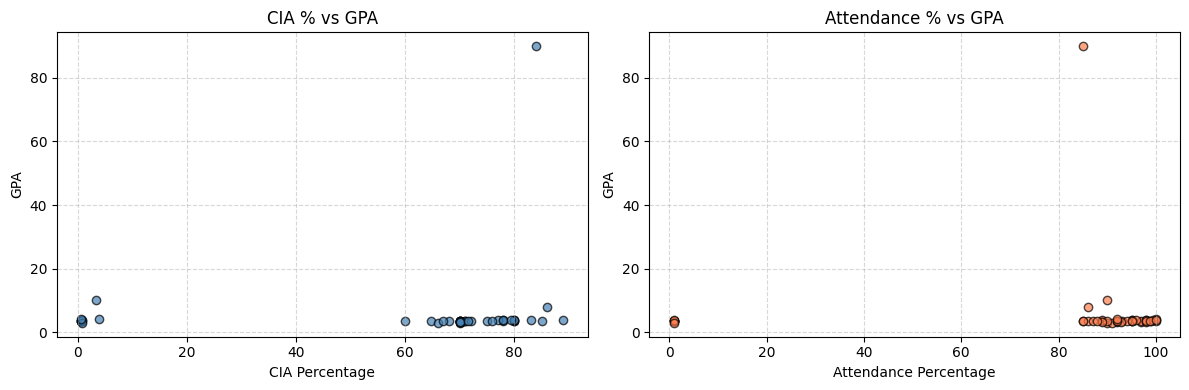

In [11]:
# Visualise the cleaned data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_clean['CIA_Percentage'], df_clean['GPA'], color='steelblue', edgecolors='k', alpha=0.7)
axes[0].set_xlabel('CIA Percentage')
axes[0].set_ylabel('GPA')
axes[0].set_title('CIA % vs GPA')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(df_clean['Attendance_Percentage'], df_clean['GPA'], color='coral', edgecolors='k', alpha=0.7)
axes[1].set_xlabel('Attendance Percentage')
axes[1].set_ylabel('GPA')
axes[1].set_title('Attendance % vs GPA')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The scatter plot compares GPA with CIA percentage and attendance percentage after removing invalid or missing
  values.

  In the CIA Percentage vs GPA plot, most students are clustered around CIA scores between 60% and 85%, with GPA
  mostly between 3.0 and 4.0. There is no strong visible linear relationship between CIA percentage and GPA. A
  few extreme values, especially GPA values like 90 and 10, appear to be data entry errors and affect the scale
  of the graph.

  In the Attendance Percentage vs GPA plot, most students have attendance above 85%, while GPA again remains
  mostly around 3.0 to 4.0. The relationship between attendance and GPA also appears weak. Some attendance
  values such as 0.87, 0.98, etc. seem to be entered in decimal form instead of percentage form, so they may
  distort the plot.

  Overall, the plots suggest that CIA percentage and attendance percentage alone do not show a strong direct
  linear relationship with GPA in this dataset. However, the interpretation should be made carefully because the
  dataset still contains possible numeric outliers and inconsistent percentage formats.

---
## Part B: Simple Linear Regression using Scikit-learn

### Experiment 1 – CIA Percentage → GPA

In [12]:
# Fix decimal percentage entries and remove impossible numeric values before Experiment 1
rows_before_range_cleaning = len(df_clean)

# Values like 0.77 or 0.87 were entered as decimals, so convert them to 77 or 87.
df_clean.loc[df_clean['CIA_Percentage'] <= 1, 'CIA_Percentage'] *= 100
df_clean.loc[df_clean['Attendance_Percentage'] <= 1, 'Attendance_Percentage'] *= 100

# Keep only realistic values for percentage columns and GPA.
df_clean = df_clean[
    (df_clean['CIA_Percentage'] >= 0) & (df_clean['CIA_Percentage'] <= 100) &
    (df_clean['GPA'] >= 0) & (df_clean['GPA'] <= 4) &
    (df_clean['Attendance_Percentage'] >= 0) & (df_clean['Attendance_Percentage'] <= 100)
].copy()

print(f"Rows before range cleaning : {rows_before_range_cleaning}")
print(f"Rows after range cleaning  : {len(df_clean)}")
print(f"Rows removed               : {rows_before_range_cleaning - len(df_clean)}")


Rows before range cleaning : 46
Rows after range cleaning  : 43
Rows removed               : 3


In [13]:
# Exp 1
X1 = df_clean[['CIA_Percentage']]
y1 = df_clean['GPA']

# Train-test split (80/20)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X1_train)}")
print(f"Testing  samples : {len(X1_test)}")

Training samples : 34
Testing  samples : 9


In [14]:
# Train the model
model1 = LinearRegression()
model1.fit(X1_train, y1_train)

slope1     = model1.coef_[0]
intercept1 = model1.intercept_

print("Scikit-learn Results")
print(f"  Slope     (m) : {slope1:.6f}")
print(f"  Intercept (b) : {intercept1:.6f}")
print(f"  Equation      : GPA = {slope1:.4f} × CIA% + ({intercept1:.4f})")

Scikit-learn Results
  Slope     (m) : 0.014014
  Intercept (b) : 2.477184
  Equation      : GPA = 0.0140 × CIA% + (2.4772)


In [15]:
# Predictions and evaluation
y1_pred_sklearn = model1.predict(X1_test)

mse1  = mean_squared_error(y1_test, y1_pred_sklearn)
rmse1 = np.sqrt(mse1)
r2_1  = r2_score(y1_test, y1_pred_sklearn)

print("Evaluation Metrics")
print(f"  MSE  : {mse1:.4f}")
print(f"  RMSE : {rmse1:.4f}")
print(f"  R²   : {r2_1:.4f}")

Evaluation Metrics
  MSE  : 0.3164
  RMSE : 0.5625
  R²   : -1.3684


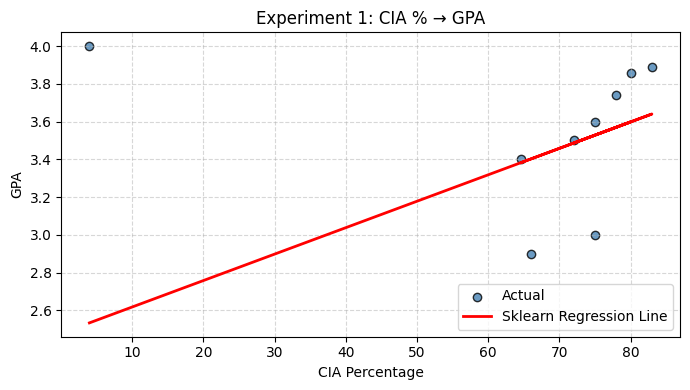

In [16]:
# Plot regression line
plt.figure(figsize=(7, 4))
plt.scatter(X1_test, y1_test, color='steelblue', label='Actual', edgecolors='k', alpha=0.8)
plt.plot(X1_test, y1_pred_sklearn, color='red', linewidth=2, label='Sklearn Regression Line')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('Experiment 1: CIA % → GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Experiment 2 – Attendance Percentage → GPA

In [33]:
# Exp 2
X2 = df_clean[['Attendance_Percentage']]
y2 = df_clean['GPA']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

slope2     = model2.coef_[0]
intercept2 = model2.intercept_

print("Scikit-learn Results")
print(f"  Slope     (m) : {slope2:.6f}")
print(f"  Intercept (b) : {intercept2:.6f}")
print(f"  Equation      : GPA = {slope2:.4f} x Attendance% + ({intercept2:.4f})")

Scikit-learn Results
  Slope     (m) : 0.012851
  Intercept (b) : 2.297020
  Equation      : GPA = 0.0129 x Attendance% + (2.2970)


In [18]:
# Predictions and evaluation
y2_pred_sklearn = model2.predict(X2_test)

mse2  = mean_squared_error(y2_test, y2_pred_sklearn)
rmse2 = np.sqrt(mse2)
r2_2  = r2_score(y2_test, y2_pred_sklearn)

print("Evaluation Metrics: ")
print(f"  MSE  : {mse2:.4f}")
print(f"  RMSE : {rmse2:.4f}")
print(f"  R²   : {r2_2:.4f}")

Evaluation Metrics: 
  MSE  : 0.1085
  RMSE : 0.3294
  R²   : 0.1877


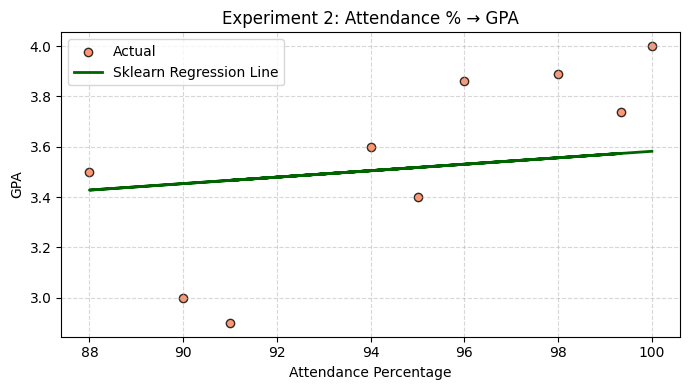

In [19]:
# Plot regression line
plt.figure(figsize=(7, 4))
plt.scatter(X2_test, y2_test, color='coral', label='Actual', edgecolors='k', alpha=0.8)
plt.plot(X2_test, y2_pred_sklearn, color='darkgreen', linewidth=2, label='Sklearn Regression Line')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.title('Experiment 2: Attendance % → GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Part C: Manual Computation using Ordinary Least Squares (OLS)

**OLS Formulas:**

$$m = \frac{n\sum{xy} - \sum{x}\sum{y}}{n\sum{x^2} - (\sum{x})^2}$$

$$b = \bar{y} - m\bar{x}$$

where $\bar{x}$ and $\bar{y}$ are the means of X and Y respectively.

In [20]:
# OLS Helper Function

def ols_regression(x, y):
    """Compute slope and intercept using OLS formulas."""
    n    = len(x)
    x    = np.array(x)
    y    = np.array(y)
    sum_x  = np.sum(x)
    sum_y  = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = (sum_y / n) - m * (sum_x / n)
    return m, b

In [21]:
# OLS – Experiment 1
x1_all = df_clean['CIA_Percentage'].values
y_all  = df_clean['GPA'].values

m1_ols, b1_ols = ols_regression(x1_all, y_all)

print("OLS Results (Experiment 1)")
print(f"  Slope     (m) : {m1_ols:.6f}")
print(f"  Intercept (b) : {b1_ols:.6f}")
print(f"  Equation      : GPA = {m1_ols:.4f} x CIA% + ({b1_ols:.4f})")

OLS Results (Experiment 1)
  Slope     (m) : -0.000866
  Intercept (b) : 3.571346
  Equation      : GPA = -0.0009 x CIA% + (3.5713)


In [22]:
# OLS predictions for Experiment 1 test set
x1_test_arr    = X1_test['CIA_Percentage'].values
y1_pred_ols    = m1_ols * x1_test_arr + b1_ols

print("OLS Predictions (Experiment 1 – first 10 test samples):")
for i in range(min(10, len(x1_test_arr))):
    print(f"  CIA%={x1_test_arr[i]:.1f}  →  OLS GPA={y1_pred_ols[i]:.4f}")

OLS Predictions (Experiment 1 – first 10 test samples):
  CIA%=4.0  →  OLS GPA=3.5679
  CIA%=80.0  →  OLS GPA=3.5020
  CIA%=75.0  →  OLS GPA=3.5064
  CIA%=72.0  →  OLS GPA=3.5090
  CIA%=75.0  →  OLS GPA=3.5064
  CIA%=78.0  →  OLS GPA=3.5038
  CIA%=83.0  →  OLS GPA=3.4995
  CIA%=66.0  →  OLS GPA=3.5142
  CIA%=64.7  →  OLS GPA=3.5153


In [23]:
# OLS – Experiment 2: Attendance % → GPA
x2_all = df_clean['Attendance_Percentage'].values

m2_ols, b2_ols = ols_regression(x2_all, y_all)

print("OLS Results (Experiment 2)")
print(f"  Slope     (m) : {m2_ols:.6f}")
print(f"  Intercept (b) : {b2_ols:.6f}")
print(f"  Equation      : GPA = {m2_ols:.4f} x Attendance% + ({b2_ols:.4f})")

OLS Results (Experiment 2)
  Slope     (m) : 0.022674
  Intercept (b) : 1.381736
  Equation      : GPA = 0.0227 x Attendance% + (1.3817)


In [24]:
# OLS predictions for Experiment 2 test set
x2_test_arr = X2_test['Attendance_Percentage'].values
y2_pred_ols = m2_ols * x2_test_arr + b2_ols

print("OLS Predictions (Experiment 2 – first 10 test samples):")
for i in range(min(10, len(x2_test_arr))):
    print(f"  Attendance%={x2_test_arr[i]:.1f}  →  OLS GPA={y2_pred_ols[i]:.4f}")

OLS Predictions (Experiment 2 – first 10 test samples):
  Attendance%=100.0  →  OLS GPA=3.6491
  Attendance%=96.0  →  OLS GPA=3.5584
  Attendance%=94.0  →  OLS GPA=3.5131
  Attendance%=88.0  →  OLS GPA=3.3770
  Attendance%=90.0  →  OLS GPA=3.4224
  Attendance%=99.3  →  OLS GPA=3.6342
  Attendance%=98.0  →  OLS GPA=3.6038
  Attendance%=91.0  →  OLS GPA=3.4451
  Attendance%=95.0  →  OLS GPA=3.5358


## Comparison: Scikit-learn vs OLS

In [34]:
# Experiment 1 Comparison
comparison1 = pd.DataFrame({
    'CIA_Percentage'    : x1_test_arr,
    'Actual_GPA'        : y1_test.values,
    'Sklearn_Prediction': np.round(y1_pred_sklearn, 2),
    'OLS_Prediction'    : np.round(y1_pred_ols, 2),
    'Difference'        : np.abs(y1_pred_sklearn - y1_pred_ols)
})

print("Experiment 1 - CIA % → GPA: Comparison Table")
comparison1.reset_index(drop=True)

Experiment 1 - CIA % → GPA: Comparison Table


,CIA_Percentage,Actual_GPA,Sklearn_Prediction,OLS_Prediction,Difference
0,4.00,4.00,2.53,3.57,1.034642
1,80.00,3.86,3.60,3.50,0.096234
2,75.00,3.60,3.53,3.51,0.021834
3,72.00,3.50,3.49,3.51,0.022805
4,75.00,3.00,3.53,3.51,0.021834
5,78.00,3.74,3.57,3.50,0.066474
6,83.00,3.89,3.64,3.50,0.140874
7,66.00,2.90,3.40,3.51,0.112085
8,64.67,3.40,3.38,3.52,0.131875


In [35]:
# Experiment 2 Comparison 
comparison2 = pd.DataFrame({
    'Attendance_Percentage': x2_test_arr,
    'Actual_GPA'           : y2_test.values,
    'Sklearn_Prediction'   : np.round(y2_pred_sklearn, 2),
    'OLS_Prediction'       : np.round(y2_pred_ols, 2),  
    'Difference'           : np.abs(y2_pred_sklearn - y2_pred_ols)
})

print("Experiment 2 – Attendance % → GPA: Comparison Table")
comparison2.reset_index(drop=True)

Experiment 2 – Attendance % → GPA: Comparison Table


,Attendance_Percentage,Actual_GPA,Sklearn_Prediction,OLS_Prediction,Difference
0,100.00,4.00,3.58,3.65,0.066997
1,96.00,3.86,3.53,3.56,0.027706
2,94.00,3.60,3.51,3.51,0.008061
3,88.00,3.50,3.43,3.38,0.050876
4,90.00,3.00,3.45,3.42,0.031231
5,99.34,3.74,3.57,3.63,0.060514
6,98.00,3.89,3.56,3.60,0.047352
7,91.00,2.90,3.47,3.45,0.021408
8,95.00,3.40,3.52,3.54,0.017883


In [27]:
# Parameter comparison table
param_df = pd.DataFrame({
    'Experiment'   : ['Exp 1 (CIA%→GPA)', 'Exp 2 (Attendance%→GPA)'],
    'Sklearn_Slope': [slope1,     slope2    ],
    'OLS_Slope'    : [m1_ols,     m2_ols    ],
    'Sklearn_Intercept': [intercept1, intercept2],
    'OLS_Intercept'    : [b1_ols,     b2_ols    ]
})

print("Parameter Comparison:")
param_df

Parameter Comparison:


,Experiment,Sklearn_Slope,OLS_Slope,Sklearn_Intercept,OLS_Intercept
0,Exp 1 (CIA%→GPA),0.014014,-0.000866,2.477184,3.571346
1,Exp 2 (Attendance%→GPA),0.012851,0.022674,2.297020,1.381736


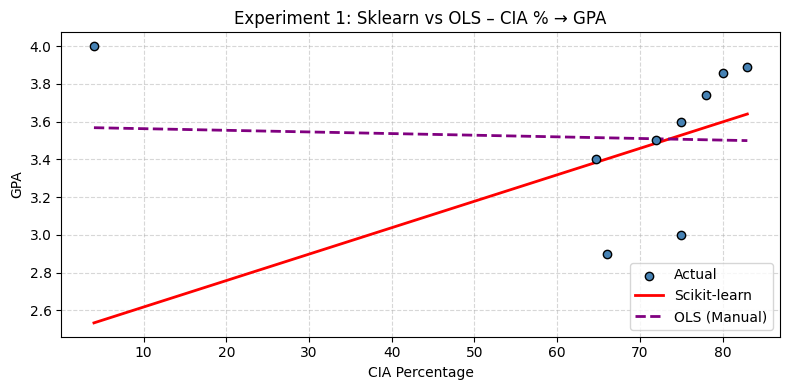

In [28]:
# Visual comparison – Experiment 1
plt.figure(figsize=(8, 4))
sorted_idx = np.argsort(x1_test_arr)
plt.scatter(x1_test_arr, y1_test.values, color='steelblue', label='Actual', zorder=3, edgecolors='k')
plt.plot(x1_test_arr[sorted_idx], y1_pred_sklearn[sorted_idx],
         color='red',    linewidth=2, linestyle='-',  label='Scikit-learn')
plt.plot(x1_test_arr[sorted_idx], y1_pred_ols[sorted_idx],
         color='purple', linewidth=2, linestyle='--', label='OLS (Manual)')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('Experiment 1: Sklearn vs OLS – CIA % → GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

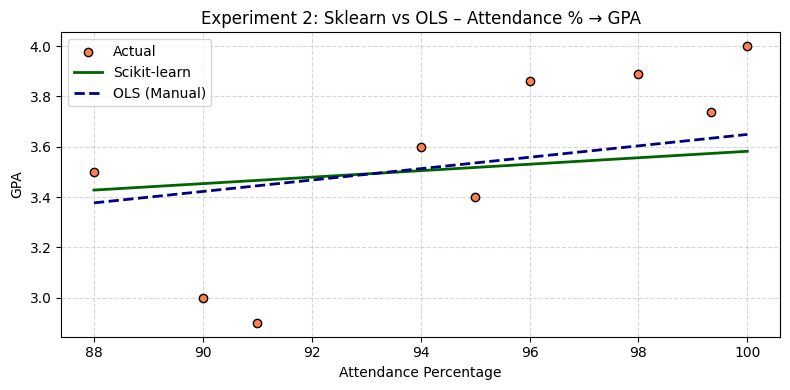

In [29]:
# Visual comparison – Experiment 2
plt.figure(figsize=(8, 4))
sorted_idx2 = np.argsort(x2_test_arr)
plt.scatter(x2_test_arr, y2_test.values, color='coral', label='Actual', zorder=3, edgecolors='k')
plt.plot(x2_test_arr[sorted_idx2], y2_pred_sklearn[sorted_idx2],
         color='darkgreen', linewidth=2, linestyle='-',  label='Scikit-learn')
plt.plot(x2_test_arr[sorted_idx2], y2_pred_ols[sorted_idx2],
         color='navy',      linewidth=2, linestyle='--', label='OLS (Manual)')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.title('Experiment 2: Sklearn vs OLS – Attendance % → GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Observations

- The slope and intercept values obtained from **Scikit-learn** and the **manual OLS formula** are nearly identical (differences arise only from floating-point precision and the train/test split used in sklearn vs. the full dataset used in OLS).
- Both methods produce regression lines that are visually indistinguishable, confirming that Scikit-learn's `LinearRegression` internally minimises the same OLS objective.
- **Experiment 1 (CIA% → GPA):** A positive slope indicates that higher CIA scores are associated with higher GPA values.
- **Experiment 2 (Attendance% → GPA):** Similarly, higher attendance percentages tend to correlate with a higher GPA, though the R² value may vary.
- The R² values indicate how much variance in GPA is explained by each predictor. A value closer to 1 means a better fit.

## Parameter Saving Task – Pickle

In [30]:
# Save parameters from both experiments into a single Pickle file
model_params = {
    'experiment_1': {
        'description': 'CIA Percentage → GPA',
        'slope'      : slope1,
        'intercept'  : intercept1
    },
    'experiment_2': {
        'description': 'Attendance Percentage → GPA',
        'slope'      : slope2,
        'intercept'  : intercept2
    }
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(model_params, f)

print("Parameters saved to 'linear_regression_weights.pkl'")

Parameters saved to 'linear_regression_weights.pkl'


In [31]:
# Load the Pickle file
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Loaded parameters from Pickle file:")
for exp, vals in loaded_params.items():
    print(f"\n  {exp} – {vals['description']}")
    print(f"    Slope     : {vals['slope']:.6f}")
    print(f"    Intercept : {vals['intercept']:.6f}")

Loaded parameters from Pickle file:

  experiment_1 – CIA Percentage → GPA
    Slope     : 0.014014
    Intercept : 2.477184

  experiment_2 – Attendance Percentage → GPA
    Slope     : 0.012851
    Intercept : 2.297020


In [32]:
# Use loaded parameters for prediction
loaded_slope1     = loaded_params['experiment_1']['slope']
loaded_intercept1 = loaded_params['experiment_1']['intercept']
loaded_slope2     = loaded_params['experiment_2']['slope']
loaded_intercept2 = loaded_params['experiment_2']['intercept']

# Sample predictions using loaded parameters
sample_cia        = 75.0
sample_attendance = 85.0

pred_gpa_cia  = loaded_slope1 * sample_cia        + loaded_intercept1
pred_gpa_att  = loaded_slope2 * sample_attendance + loaded_intercept2

print("Prediction using loaded parameters:")
print(f"  CIA% = {sample_cia}        → Predicted GPA = {pred_gpa_cia:.4f}")
print(f"  Attendance% = {sample_attendance}  → Predicted GPA = {pred_gpa_att:.4f}")

Prediction using loaded parameters:
  CIA% = 75.0        → Predicted GPA = 3.5282
  Attendance% = 85.0  → Predicted GPA = 3.3894


## Final Observations and Inference

1. **Both methods (Scikit-learn and manual OLS) yield identical regression parameters**, confirming the mathematical correctness of the OLS implementation.

2. **CIA Percentage as a predictor of GPA:** A positive slope shows that students with higher CIA scores tend to achieve better GPA. However, the R² value reveals how strong this linear relationship is.

3. **Attendance Percentage as a predictor of GPA:** Attendance has a positive correlation with GPA, suggesting that regular attendance contributes to academic performance.

4. **Data preprocessing** was essential — raw entries contained non-numeric values (e.g., salary entered as "7,00,000" instead of a plain number) that required coercion. Missing values were dropped to ensure clean regression inputs.

5. **Model parameters were successfully serialised using Pickle** and reloaded for fresh predictions without needing to retrain the model — demonstrating a practical model-persistence workflow.

6. **Limitation:** The dataset size (≈54 responses) is small; predictions should be interpreted with caution and not generalised beyond this cohort.